<a href="https://colab.research.google.com/github/JoseLReyna/Tareas-MCU-IA-2026/blob/EjemploZara/EjemploCaso_Zara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# =========================
# 1) CARGA DEL CSV RAW (Google Trends)
# =========================
# Ruta del archivo exportado desde Google Trends (ej: multiTimeline.csv)
# Asegúrate de que esta ruta sea correcta, especialmente si el archivo está en
# Google Drive.
input_path = "/content/drive/MyDrive/0. EjemploZara/multiTimeline.csv"

# Google Trends suele incluir 2 filas de metadatos antes del header real
df_raw = pd.read_csv(input_path, skiprows=2)

# =========================
# 2) SELECCIÓN Y RENOMBRE DE COLUMNAS (4 columnas finales)
# =========================
# En el CSV de Google Trends, la primera columna suele ser "Month" o "Date"
# y las siguientes son las series de cada término.
# Aquí asumimos 4 columnas exactas: fecha + 3 términos (Zara, Shein, Temu).
df = df_raw.iloc[:, :4].copy()
df.columns = ["fecha", "zara", "shein", "temu"]

# =========================
# 3) TRANSFORMACIÓN DE TIPOS
# =========================
# 3.1 Fecha a datetime
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# 3.2 Tendencias a numérico (valores no numéricos -> NaN)
for col in ["zara", "shein", "temu"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4) VALIDACIÓN BÁSICA (sanity checks)
# =========================
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Asegura que la fecha no tenga NaT
if df["fecha"].isnull().any():
    raise ValueError("Hay fechas no parseables (NaT). Revisa el formato del CSV.")

# =========================
# 5) GUARDADO DEL DATASET FINAL (analysis-ready)
# =========================
output_path = "trends_zara_shein_temu_analysis_ready.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ Archivo limpio guardado en: {output_path}")
print("\nPreview:")
print(df.head())

Tipos de datos:
fecha    datetime64[ns]
zara              int64
shein           float64
temu            float64
dtype: object

Valores nulos por columna:
fecha     0
zara      0
shein    15
temu     45
dtype: int64

✅ Archivo limpio guardado en: trends_zara_shein_temu_analysis_ready.csv

Preview:
       fecha  zara  shein  temu
0 2004-01-01     8    0.0   0.0
1 2004-02-01     8    0.0   0.0
2 2004-03-01     7    0.0   0.0
3 2004-04-01     9    0.0   0.0
4 2004-05-01     8    0.0   0.0


### Análisis Descriptivo de la Serie Temporal para Zara

Vamos a visualizar la evolución de las búsquedas de 'Zara' a lo largo del tiempo y a obtener algunas estadísticas descriptivas.

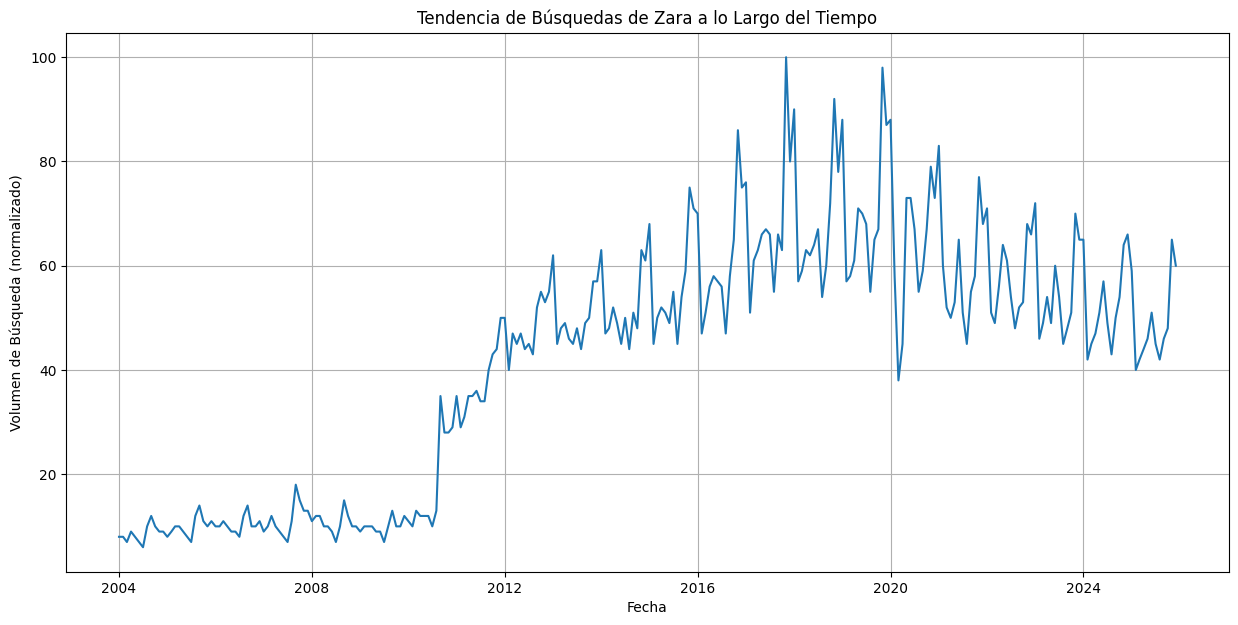

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(x='fecha', y='zara', data=df)
plt.title('Tendencia de Búsquedas de Zara a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Volumen de Búsqueda (normalizado)')
plt.grid(True)
plt.show()


In [4]:
print("Estadísticas Descriptivas para la Serie Temporal de Zara:")
print(df['zara'].describe())


Estadísticas Descriptivas para la Serie Temporal de Zara:
count    264.000000
mean      42.159091
std       23.889425
min        6.000000
25%       12.000000
50%       48.000000
75%       59.000000
max      100.000000
Name: zara, dtype: float64


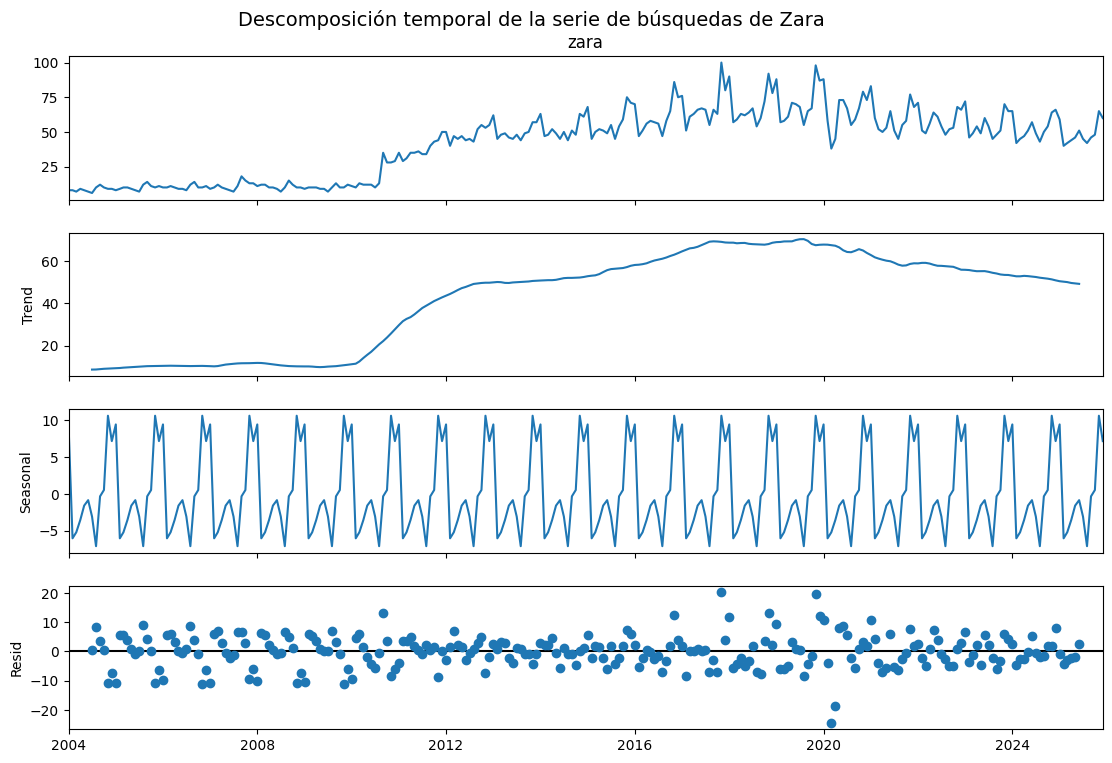

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# 1) CARGA DE DATOS LIMPIOS
# =========================
path = "trends_zara_shein_temu_analysis_ready.csv"
df = pd.read_csv(path)

# Asegurar tipo datetime
df["fecha"] = pd.to_datetime(df["fecha"])

# Establecer fecha como índice temporal
df = df.set_index("fecha")

# =========================
# 2) SELECCIÓN DE LA SERIE ZARA
# =========================
zara_ts = df["zara"].dropna()

# =========================
# 3) DESCOMPOSICIÓN TEMPORAL
# =========================
decomposition = seasonal_decompose(
    zara_ts,
    model="additive",
    period=12
)

# =========================
# 4) VISUALIZACIÓN
# =========================
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Descomposición temporal de la serie de búsquedas de Zara", fontsize=14)
plt.show()

